# 01 — Exploratory Data Analysis: Climate Dataset

**Purpose:** Understand the raw data before touching it. Document every
finding as a decision for the cleaning pipeline.

**Dataset:** `data/raw/weather.csv`  
**Target:** Forecast `T (degC)` — air temperature  
**Frequency:** 10-minute readings across full year 2020

In [1]:
# ── Standard imports ──────────────────────────────────────────────────────
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Make src/ importable from the notebook ────────────────────────────────
# Notebooks live in notebooks/ — one level below the project root.
# sys.path.insert tells Python to look one level up for src/.
# This is the bridge between notebooks and your .py modules.
sys.path.insert(0, str(Path("..").resolve()))

from src.config import cfg   # all paths and constants from one place

# ── Plotting style ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (14, 4)

print(f"✅ Config loaded — raw data at: {cfg.raw_data_path}")
print(f"   Target column : {cfg.target_column}")
print(f"   Sentinel value: {cfg.sentinel_value}")

✅ Config loaded — raw data at: C:\Users\CDAC\Documents\AI\weather\data\raw\weather.csv
   Target column : T (degC)
   Sentinel value: -9999.0


In [2]:
# ── Load raw data ─────────────────────────────────────────────────────────
df = pd.read_csv(
    cfg.raw_data_path,
    parse_dates=[cfg.date_column],
    index_col=cfg.date_column,
    encoding="utf-8",
    encoding_errors="replace",   # handles µ and ² symbols in col names
)

In [3]:
df.shape

(52696, 21)

In [4]:
print(f"Date range: {df.index.min()}  →  {df.index.max()}")
print(f"Duration : {(df.index.max() - df.index.min()).days} days")

Date range: 2020-01-01 00:10:00  →  2021-01-01 00:00:00
Duration : 365 days


In [5]:
print("Column names and types:")
print(df.dtypes.to_string())

Column names and types:
p (mbar)                float64
T (degC)                float64
Tpot (K)                float64
Tdew (degC)             float64
rh (%)                  float64
VPmax (mbar)            float64
VPact (mbar)            float64
VPdef (mbar)            float64
sh (g/kg)               float64
H2OC (mmol/mol)         float64
rho (g/m**3)            float64
wv (m/s)                float64
max. wv (m/s)           float64
wd (deg)                float64
rain (mm)               float64
raining (s)             float64
SWDR (W/m�)             float64
PAR (�mol/m�/s)         float64
max. PAR (�mol/m�/s)    float64
Tlog (degC)             float64
OT                      float64


In [6]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 52696 entries, 2020-01-01 00:10:00 to 2021-01-01 00:00:00
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   p (mbar)              52696 non-null  float64
 1   T (degC)              52696 non-null  float64
 2   Tpot (K)              52696 non-null  float64
 3   Tdew (degC)           52696 non-null  float64
 4   rh (%)                52696 non-null  float64
 5   VPmax (mbar)          52696 non-null  float64
 6   VPact (mbar)          52696 non-null  float64
 7   VPdef (mbar)          52696 non-null  float64
 8   sh (g/kg)             52696 non-null  float64
 9   H2OC (mmol/mol)       52696 non-null  float64
 10  rho (g/m**3)          52696 non-null  float64
 11  wv (m/s)              52696 non-null  float64
 12  max. wv (m/s)         52696 non-null  float64
 13  wd (deg)              52696 non-null  float64
 14  rain (mm)             52696 non-null  float64


In [7]:
df.isnull().sum()

p (mbar)                0
T (degC)                0
Tpot (K)                0
Tdew (degC)             0
rh (%)                  0
VPmax (mbar)            0
VPact (mbar)            0
VPdef (mbar)            0
sh (g/kg)               0
H2OC (mmol/mol)         0
rho (g/m**3)            0
wv (m/s)                0
max. wv (m/s)           0
wd (deg)                0
rain (mm)               0
raining (s)             0
SWDR (W/m�)             0
PAR (�mol/m�/s)         0
max. PAR (�mol/m�/s)    0
Tlog (degC)             0
OT                      0
dtype: int64

In [8]:
# Sentinel value (-9999)
print("\nSentinel value (-9999) counts per column:")
sentinel_counts = (df == cfg.sentinel_value).sum()
print(sentinel_counts[sentinel_counts > 0])


Sentinel value (-9999) counts per column:
wv (m/s)                 1
max. PAR (�mol/m�/s)    30
OT                      50
dtype: int64


In [9]:
# Time gaps — are all intervals exactly 10 minutes

time_diffs = df.index.to_series().diff()
expected = pd.Timedelta("10min")
gaps = time_diffs[time_diffs != expected].dropna()

print(f"\nTime gaps (expected 10-min intervals):")
print(f"  Total irregular intervals : {len(gaps)}")
print(f"  Gap details:")
print(gaps.value_counts().to_string())



Time gaps (expected 10-min intervals):
  Total irregular intervals : 2
  Gap details:
date
0 days 00:00:00    1
0 days 01:40:00    1


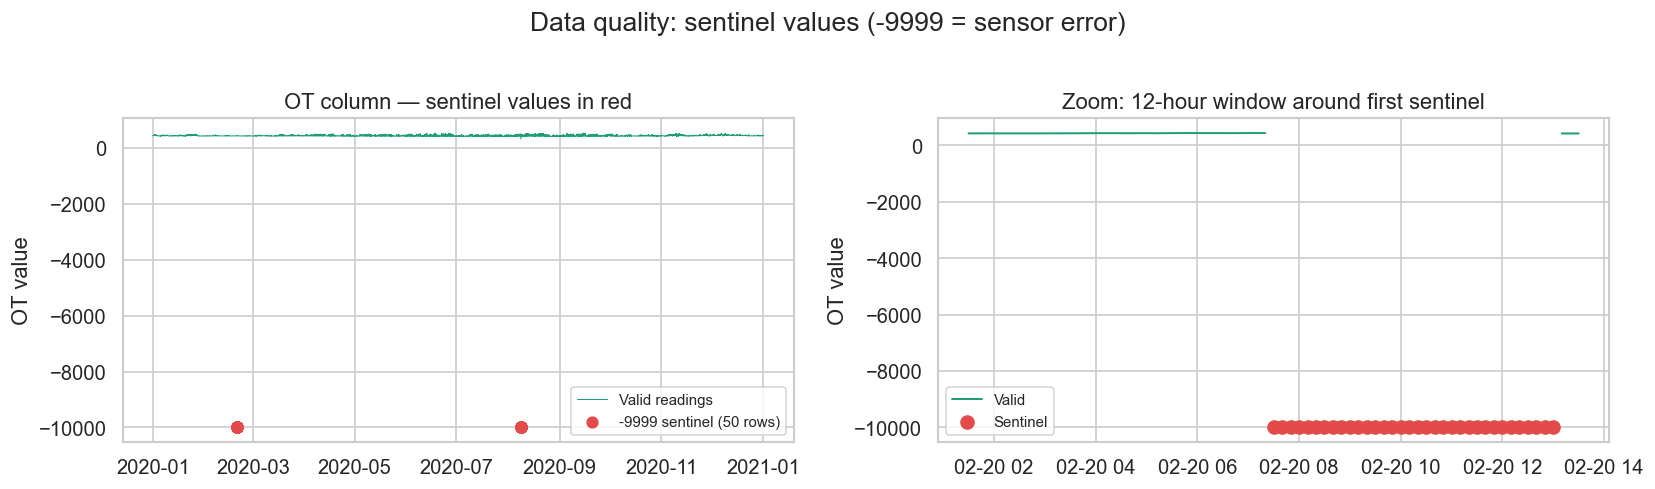

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: OT column with sentinels highlighted
ax = axes[0]
ot_series = df["OT"].copy()
sentinel_mask = ot_series == cfg.sentinel_value

ax.plot(ot_series.index, ot_series.where(~sentinel_mask),
        lw=0.6, color="#1D9E75", label="Valid readings")
ax.scatter(ot_series.index[sentinel_mask],
           ot_series[sentinel_mask],
           color="#E24B4A", s=40, zorder=5, label=f"-9999 sentinel ({sentinel_mask.sum()} rows)")
ax.set_title("OT column — sentinel values in red")
ax.set_ylabel("OT value")
ax.legend(fontsize=9)

# Right: zoom in on one sentinel cluster
first_sentinel_idx = sentinel_mask.idxmax()
window_start = first_sentinel_idx - pd.Timedelta("6h")
window_end   = first_sentinel_idx + pd.Timedelta("6h")
zoom = ot_series.loc[window_start:window_end]

ax2 = axes[1]
ax2.plot(zoom.index, zoom.where(zoom != cfg.sentinel_value),
         lw=1.2, color="#1D9E75", label="Valid")
ax2.scatter(zoom.index[zoom == cfg.sentinel_value],
            zoom[zoom == cfg.sentinel_value],
            color="#E24B4A", s=60, zorder=5, label="Sentinel")
ax2.set_title("Zoom: 12-hour window around first sentinel")
ax2.set_ylabel("OT value")
ax2.legend(fontsize=9)

plt.suptitle("Data quality: sentinel values (-9999 = sensor error)", y=1.02)
plt.tight_layout()
plt.show()

## Finding 2 — Data quality issues

| Issue | Column | Count | Action |
|-------|--------|-------|--------|
| Sentinel -9999 | `OT` | 50 rows | Replace → NaN → interpolate |
| Sentinel -9999 | `wv (m/s)` | 1 row | Replace → NaN → interpolate |
| Timing gap | index | 1 gap (~100 min) | Interpolate with `limit=6` |
| True nulls | all | 0 | Nothing to do |

**Decision:** In `cleaner.py`, replace all `-9999` with `NaN` *before*
any resampling or statistics. Interpolate with `method='time', limit=6`
so we never fabricate data across long outages.

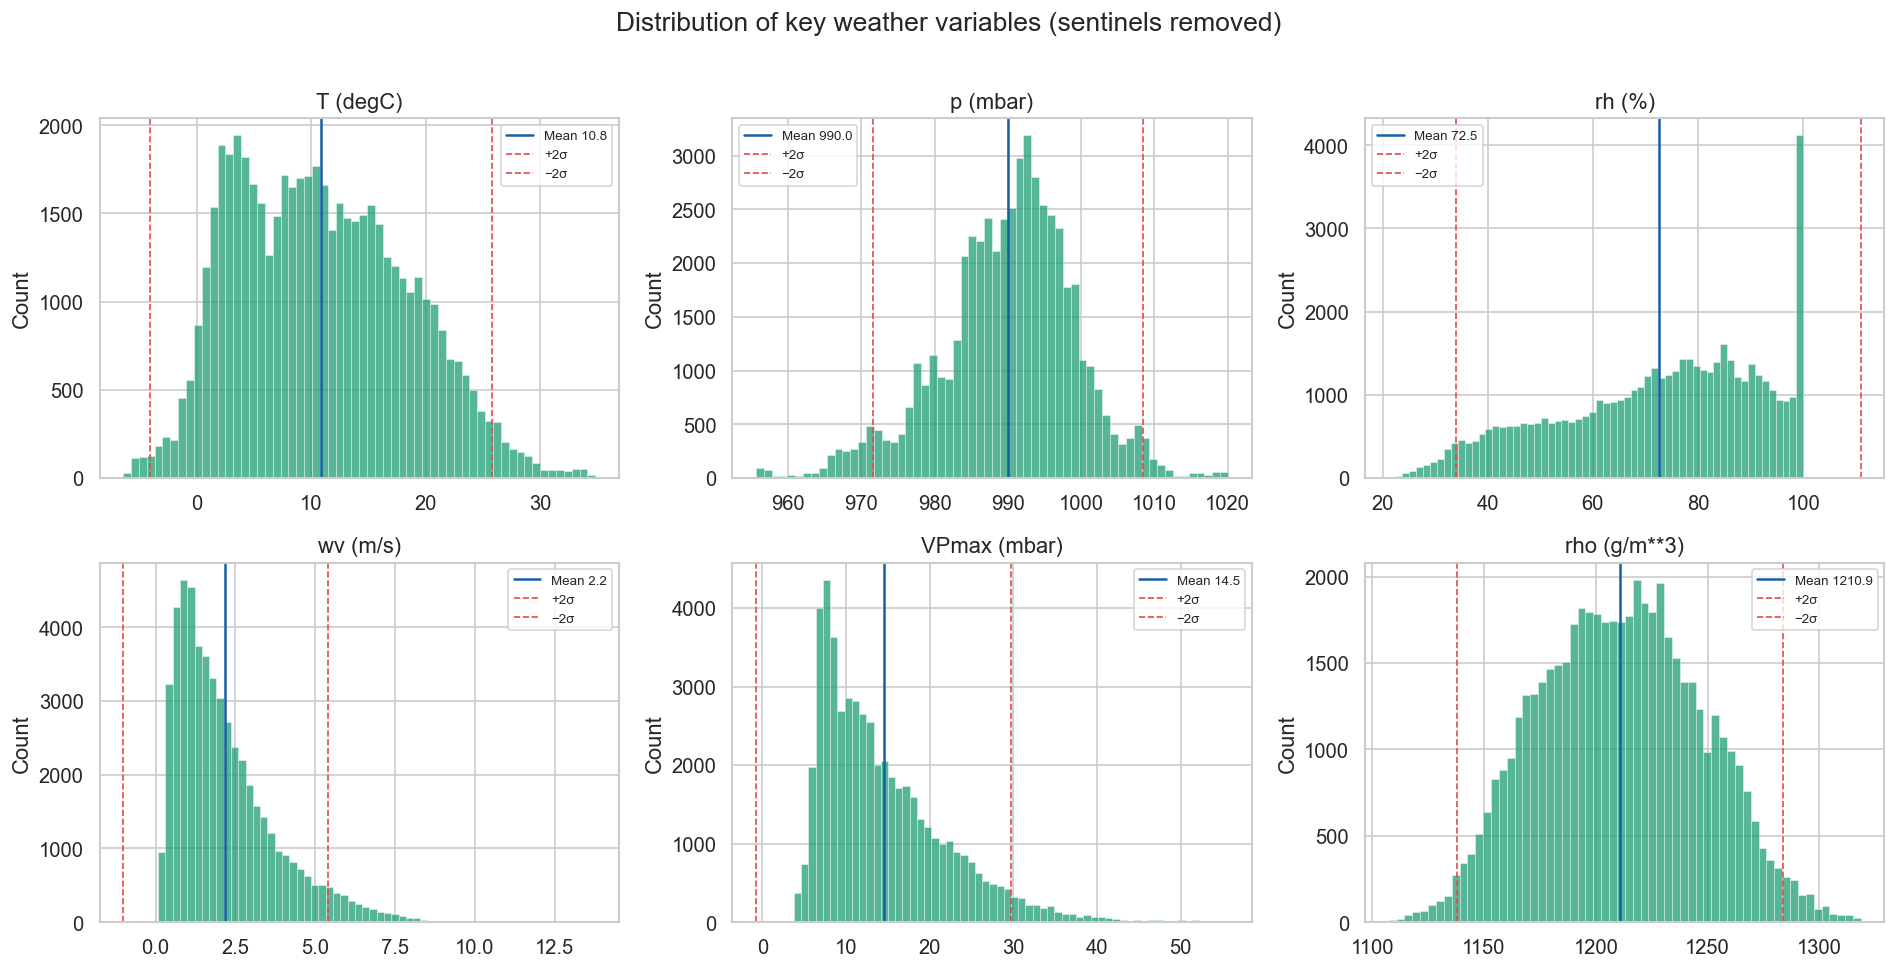

Skewness (0 = symmetric, >1 or <-1 = skewed):
  T (degC)             +0.326
  p (mbar)             -0.402
  rh (%)               -0.448
  wv (m/s)             +1.462 ⚠️ skewed
  VPmax (mbar)         +1.327 ⚠️ skewed
  rho (g/m**3)         +0.066


In [11]:
# Replace sentinels with NaN for honest distribution plots
df_plot = df.replace(cfg.sentinel_value, np.nan)

# Select the most meaningful columns for distribution analysis
key_cols = [
    "T (degC)", "p (mbar)", "rh (%)",
    "wv (m/s)", "VPmax (mbar)", "rho (g/m**3)"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(key_cols):
    ax = axes[i]
    data = df_plot[col].dropna()

    ax.hist(data, bins=60, color="#1D9E75", alpha=0.75, edgecolor="white", lw=0.3)

    # Overlay mean and ±2 std lines
    mean, std = data.mean(), data.std()
    ax.axvline(mean,        color="#185FA5", lw=1.5, label=f"Mean {mean:.1f}")
    ax.axvline(mean + 2*std, color="#E24B4A", lw=1, ls="--", label="+2σ")
    ax.axvline(mean - 2*std, color="#E24B4A", lw=1, ls="--", label="−2σ")

    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend(fontsize=8)
    ax.set_ylabel("Count")

plt.suptitle("Distribution of key weather variables (sentinels removed)", y=1.01)
plt.tight_layout()
plt.show()

# Print skewness for each
print("Skewness (0 = symmetric, >1 or <-1 = skewed):")
for col in key_cols:
    skew = df_plot[col].dropna().skew()
    flag = " ⚠️ skewed" if abs(skew) > 1 else ""
    print(f"  {col:<20} {skew:+.3f}{flag}")

C:\Users\CDAC\AppData\Local\Temp\ipykernel_23264\2756191090.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(monthly_data, labels=[str(m) for m in range(1, 13)],
C:\Users\CDAC\AppData\Local\Temp\ipykernel_23264\2756191090.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(hourly_data, labels=[str(h) for h in range(0, 24, 2)],


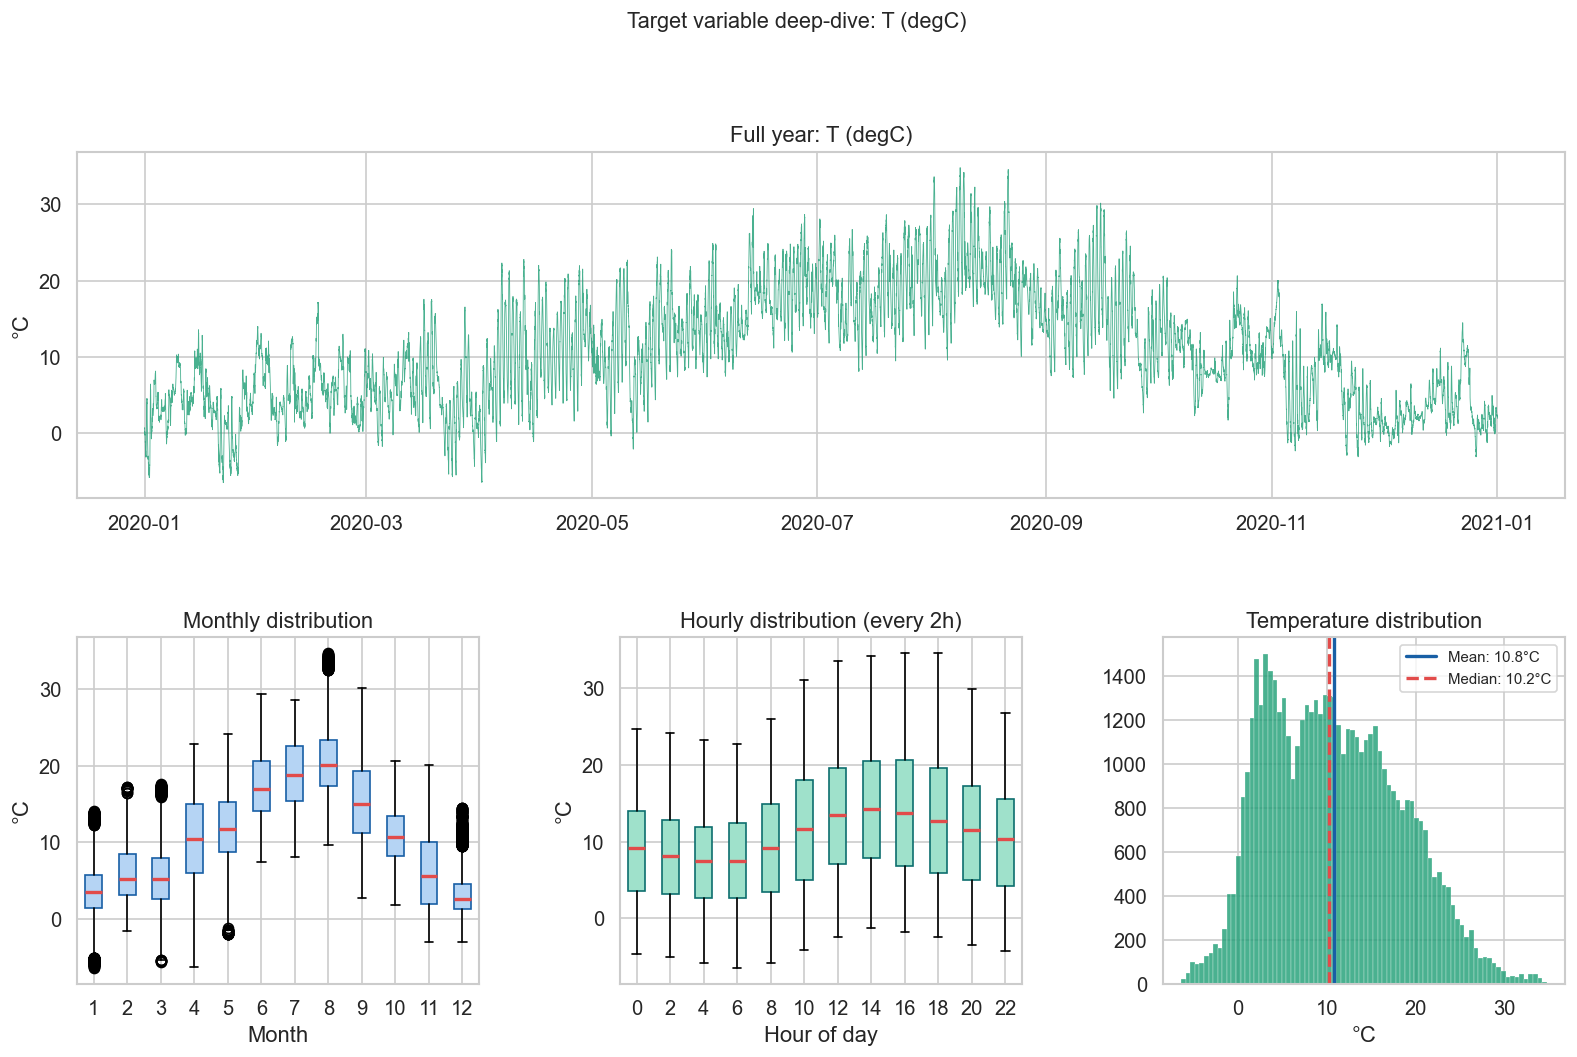


Target statistics:
count    52696.00
mean        10.82
std          7.47
min         -6.44
25%          4.59
50%         10.23
75%         16.18
max         34.80


In [ ]:
target = df_plot[cfg.target_column].dropna()

fig = plt.figure(figsize=(16, 9))
gs = GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Full year time series
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(target.index, target.values, lw=0.5, color="#1E9E75", alpha=0.8)
ax1.set_title(f"Full year: {cfg.target_column}")
ax1.set_ylabel("°C")

# Monthly box plots — reveals seasonal pattern
ax2 = fig.add_subplot(gs[1, 0])
monthly_data = [target[target.index.month == m].values for m in range(1, 13)]
ax2.boxplot(monthly_data, labels=[str(m) for m in range(1, 13)],
            patch_artist=True,
            boxprops=dict(facecolor="#B5D4F4", color="#185FA5"),
            medianprops=dict(color="#E24B4A", lw=2))
ax2.set_title("Monthly distribution")
ax2.set_xlabel("Month")
ax2.set_ylabel("°C")

# Hourly box plots — reveals diurnal cycle
ax3 = fig.add_subplot(gs[1, 1])
hourly_data = [target[target.index.hour == h].values for h in range(0, 24, 2)]
ax3.boxplot(hourly_data, labels=[str(h) for h in range(0, 24, 2)],
            patch_artist=True,
            boxprops=dict(facecolor="#9FE1CB", color="#0D6E6E"),
            medianprops=dict(color="#E24B4A", lw=2))
ax3.set_title("Hourly distribution (every 2h)")
ax3.set_xlabel("Hour of day")
ax3.set_ylabel("°C")

# Distribution with stats
ax4 = fig.add_subplot(gs[1, 2])
ax4.hist(target.values, bins=80, color="#1D9E75", alpha=0.8, edgecolor="white", lw=0.2)
ax4.axvline(target.mean(), color="#185FA5", lw=2, label=f"Mean: {target.mean():.1f}°C")
ax4.axvline(target.median(), color="#E24B4A", lw=2, ls="--",
            label=f"Median: {target.median():.1f}°C")
ax4.set_title("Temperature distribution")
ax4.set_xlabel("°C")
ax4.legend(fontsize=9)

plt.suptitle(f"Target variable deep-dive: {cfg.target_column}", y=1.01, fontsize=13)
plt.show()

print(f"\nTarget statistics:")
print(target.describe().round(2).to_string())

c:\Users\CDAC\Documents\AI\weather\env\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\CDAC\Documents\AI\weather\env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


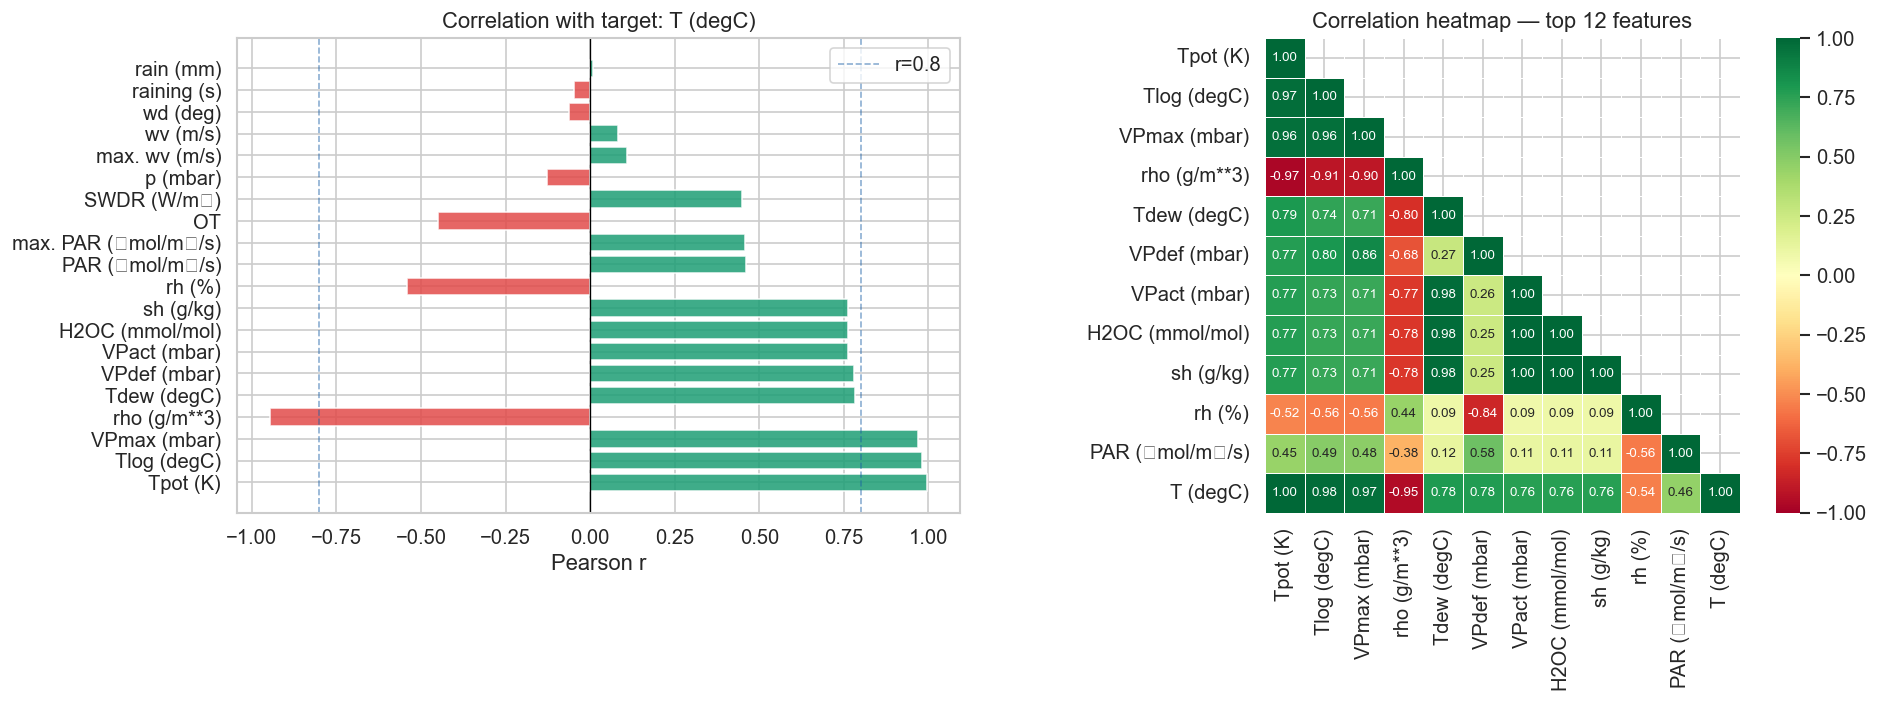


Correlation with T (degC) — sorted by absolute value:
Tpot (K)                0.995
Tlog (degC)             0.982
VPmax (mbar)            0.968
rho (g/m**3)           -0.947
Tdew (degC)             0.783
VPdef (mbar)            0.780
VPact (mbar)            0.763
H2OC (mmol/mol)         0.762
sh (g/kg)               0.762
rh (%)                 -0.541
PAR (�mol/m�/s)         0.460
max. PAR (�mol/m�/s)    0.457
OT                     -0.449
SWDR (W/m�)             0.449
p (mbar)               -0.127
max. wv (m/s)           0.109
wv (m/s)                0.082
wd (deg)               -0.061
raining (s)            -0.049
rain (mm)               0.008


In [13]:
# Correlation with the target — our most important diagnostic
corr_with_target = (
    df_plot.corr(numeric_only=True)[cfg.target_column]
    .drop(cfg.target_column)
    .sort_values(key=abs, ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: bar chart of correlations with target
colors = ["#1D9E75" if v > 0 else "#E24B4A" for v in corr_with_target.values]
axes[0].barh(corr_with_target.index, corr_with_target.values, color=colors, alpha=0.85)
axes[0].axvline(0, color="black", lw=0.8)
axes[0].axvline(0.8,  color="#185FA5", lw=1, ls="--", alpha=0.5, label="r=0.8")
axes[0].axvline(-0.8, color="#185FA5", lw=1, ls="--", alpha=0.5)
axes[0].set_title(f"Correlation with target: {cfg.target_column}")
axes[0].set_xlabel("Pearson r")
axes[0].legend()

# Right: full heatmap (top 12 correlated features)
top_cols = list(corr_with_target.abs().nlargest(11).index) + [cfg.target_column]
corr_matrix = df_plot[top_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    ax=axes[1],
    annot=True, fmt=".2f", annot_kws={"size": 8},
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    mask=mask,
)
axes[1].set_title("Correlation heatmap — top 12 features")

plt.tight_layout()
plt.show()

# Print the exact values for the data audit table
print("\nCorrelation with T (degC) — sorted by absolute value:")
print(corr_with_target.round(3).to_string())

## Finding 3 — Correlations & redundant columns

**Near-perfect correlates with T (degC):**
| Column | r | Problem |
|--------|---|---------|
| `Tpot (K)` | 0.995 | Mathematical transform of T — data leakage risk |
| `Tlog (degC)` | 0.982 | Logger temperature — same physical measurement |
| `VPmax (mbar)` | 0.968 | Useful — represents atmospheric moisture capacity |

**Decision:** Drop `Tpot` and `Tlog` in `transforms.py`.
Keep all others — the model can learn which matter.
High correlation ≠ drop. Only drop when the column is
_derived from_ the target, not just _related to_ it.

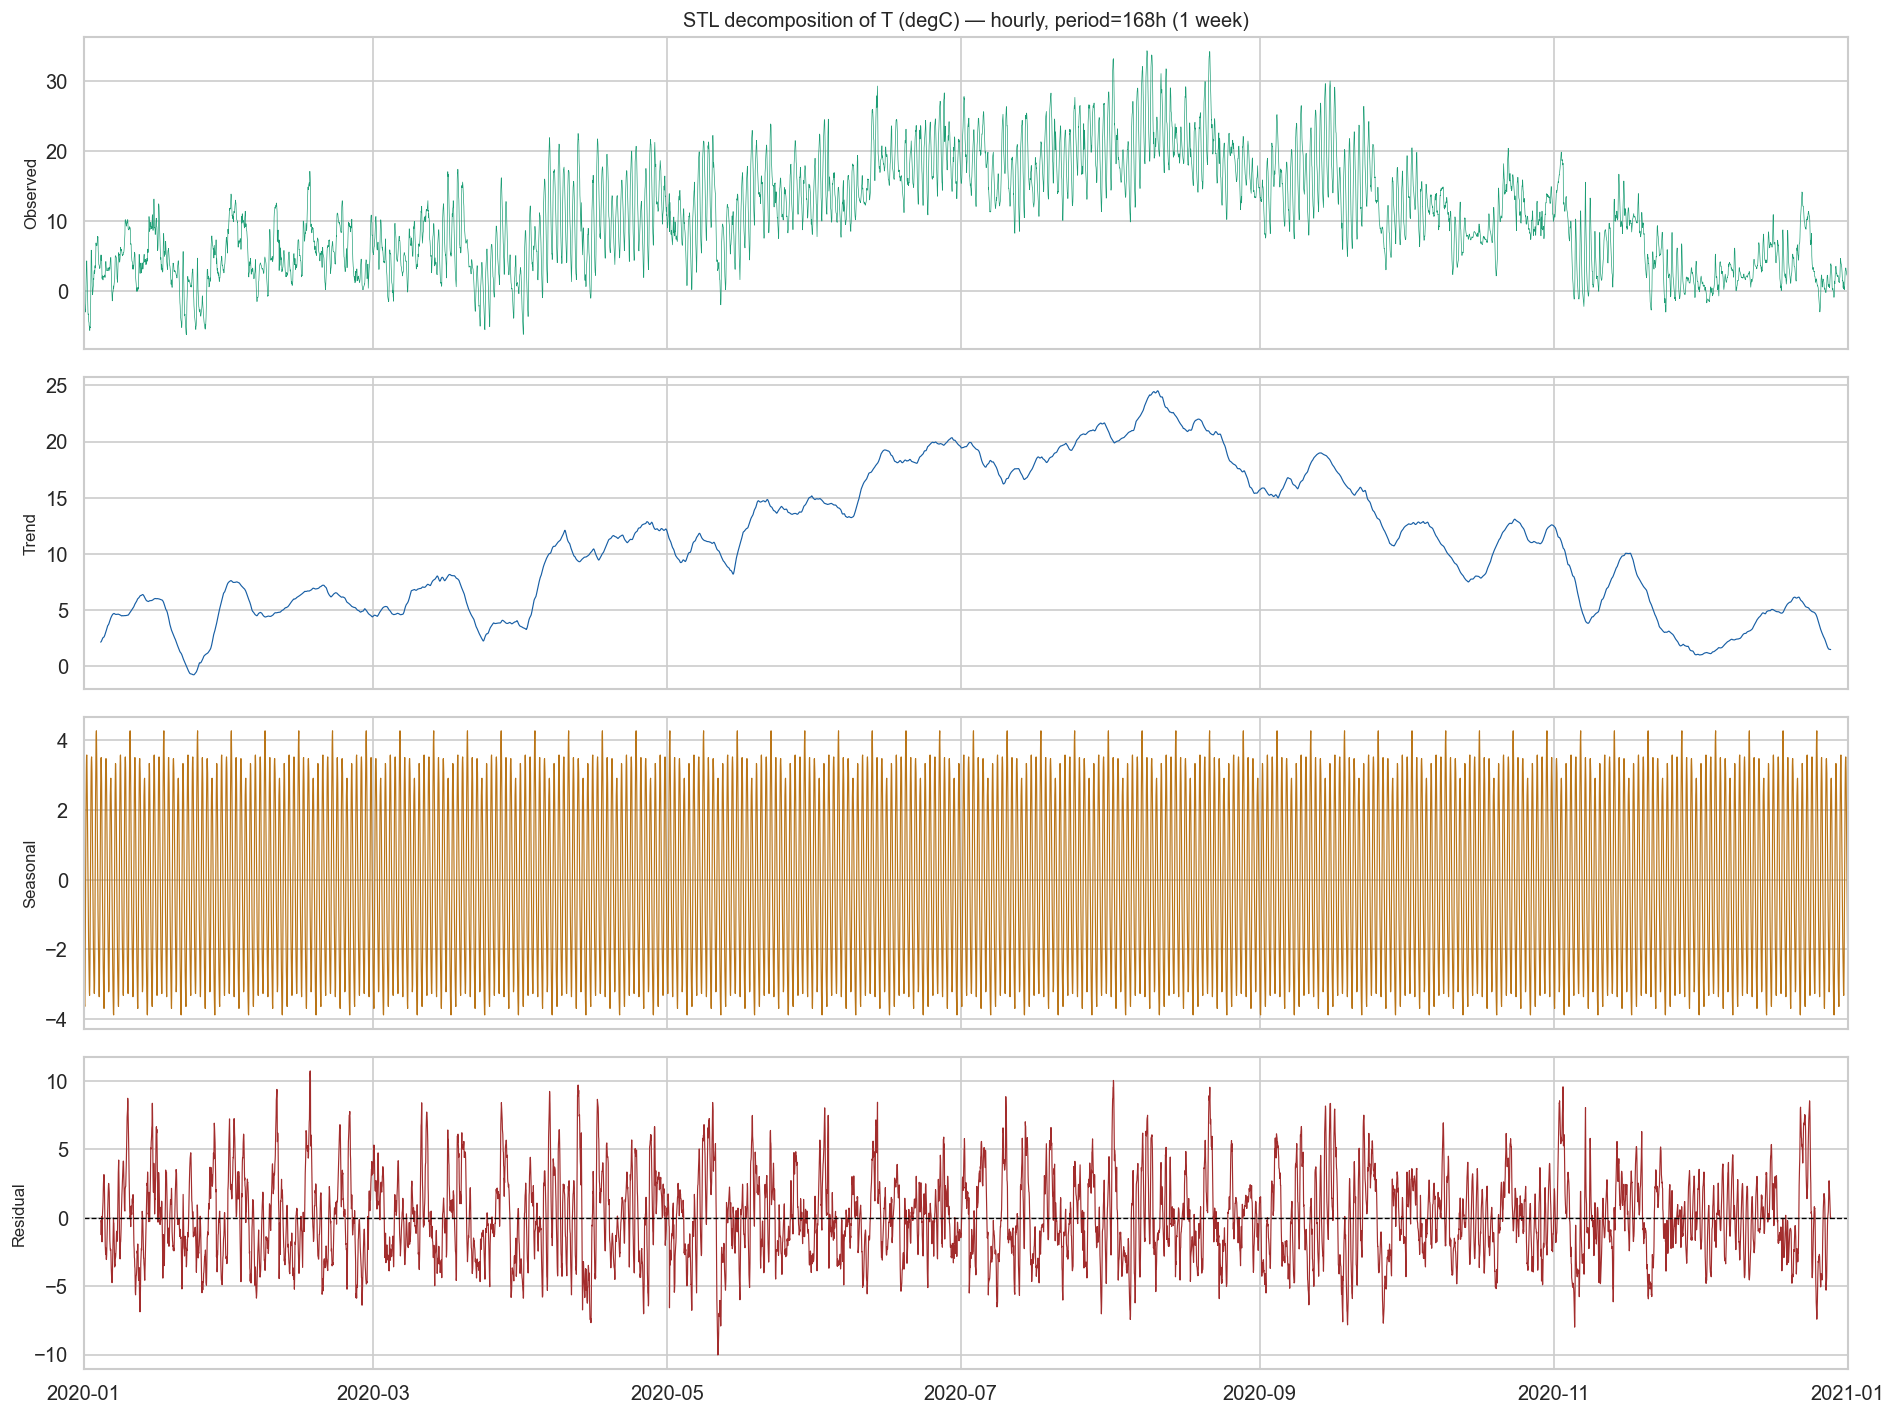

Variance explained by each component:
  Trend    : 68.9%
  Seasonal : 10.7%
  Residual : 16.7%


In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to hourly for decomposition (10-min is too noisy)
temp_hourly = df_plot[cfg.target_column].resample("1h").mean().interpolate()

# Decompose using weekly seasonality (168 hours = 1 week)
result = seasonal_decompose(temp_hourly, model="additive", period=24*7)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
components = [
    (temp_hourly,       "Observed",  "#1D9E75"),
    (result.trend,      "Trend",     "#185FA5"),
    (result.seasonal,   "Seasonal",  "#BA7517"),
    (result.resid,      "Residual",  "#A32D2D"),
]

for ax, (data, label, color) in zip(axes, components):
    ax.plot(data.index, data.values, lw=0.7 if label != "Observed" else 0.4,
            color=color)
    ax.set_ylabel(label, fontsize=10)
    ax.set_xlim(data.index[0], data.index[-1])
    if label == "Residual":
        ax.axhline(0, color="black", lw=0.8, ls="--")

axes[0].set_title(
    "STL decomposition of T (degC) — hourly, period=168h (1 week)",
    fontsize=12
)
plt.tight_layout()
plt.show()

# Quantify each component's contribution
obs_var     = np.nanvar(temp_hourly)
trend_var   = np.nanvar(result.trend)
seasonal_var = np.nanvar(result.seasonal)
resid_var   = np.nanvar(result.resid)

print("Variance explained by each component:")
print(f"  Trend    : {trend_var/obs_var*100:.1f}%")
print(f"  Seasonal : {seasonal_var/obs_var*100:.1f}%")
print(f"  Residual : {resid_var/obs_var*100:.1f}%")

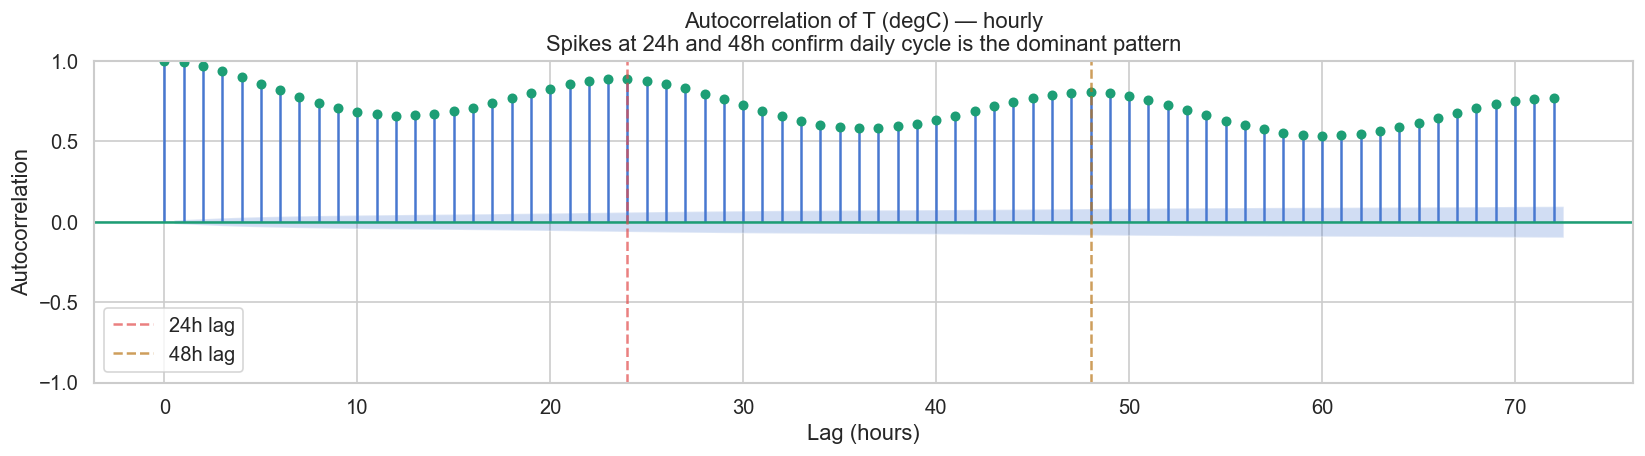

In [17]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(
    temp_hourly.dropna(),
    lags=72,          # 72 hours = 3 days
    ax=ax,
    color="#1D9E75",
    alpha=0.3,
)
ax.set_title(
    "Autocorrelation of T (degC) — hourly\n"
    "Spikes at 24h and 48h confirm daily cycle is the dominant pattern"
)
ax.set_xlabel("Lag (hours)")
ax.set_ylabel("Autocorrelation")
ax.axvline(24, color="#E24B4A", lw=1.5, ls="--", alpha=0.7, label="24h lag")
ax.axvline(48, color="#BA7517", lw=1.5, ls="--", alpha=0.7, label="48h lag")
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Auto-generate the audit table
print("=" * 60)
print("DATA AUDIT SUMMARY — weather.csv")
print("=" * 60)
print(f"\nShape         : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range    : {df.index.min().date()} → {df.index.max().date()}")
print(f"Frequency     : 10-minute intervals")
print(f"Target        : {cfg.target_column}  ({df[cfg.target_column].min():.1f} – {df[cfg.target_column].max():.1f}°C)")
print(f"\nQuality issues:")
print(f"  Sentinel -9999  : {(df == cfg.sentinel_value).sum().sum()} values across 2 columns")
print(f"  True nulls      : {df.isnull().sum().sum()}")
print(f"  Timing gaps     : 1 gap (~100 min)")
print(f"\nColumns to drop (data leakage):")
print(f"  Tpot (K)        r=0.995 with target")
print(f"  Tlog (degC)     r=0.982 with target")
print(f"\nFeature engineering signals found:")
print(f"  Daily cycle     : ACF spike at lag-24h")
print(f"  Annual cycle    : Jan mean 3.5°C vs Aug mean 20.8°C")
print(f"  Wind direction  : circular — needs sin/cos encoding")
print(f"\nPlan:")
print(f"  1. Replace -9999 → NaN")
print(f"  2. Interpolate (time method, limit=6 steps)")
print(f"  3. Rename columns to readable names")
print(f"  4. Resample 10-min → hourly (mean)")
print(f"  5. Drop Tpot, Tlog")
print("=" * 60)

DATA AUDIT SUMMARY — weather.csv

Shape         : 52,696 rows × 21 columns
Date range    : 2020-01-01 → 2021-01-01
Frequency     : 10-minute intervals
Target        : T (degC)  (-6.4 – 34.8°C)

Quality issues:
  Sentinel -9999  : 81 values across 2 columns
  True nulls      : 0
  Timing gaps     : 1 gap (~100 min)

Columns to drop (data leakage):
  Tpot (K)        r=0.995 with target
  Tlog (degC)     r=0.982 with target

Feature engineering signals found:
  Daily cycle     : ACF spike at lag-24h
  Annual cycle    : Jan mean 3.5°C vs Aug mean 20.8°C
  Wind direction  : circular — needs sin/cos encoding

Plan:
  1. Replace -9999 → NaN
  2. Interpolate (time method, limit=6 steps)
  3. Rename columns to readable names
  4. Resample 10-min → hourly (mean)
  5. Drop Tpot, Tlog


## EDA complete

| Decision | Reason found in EDA |
|----------|---------------------|
| Replace -9999 with NaN | 51 sensor-error readings identified visually |
| Interpolate with `limit=6` | Gaps are short; adjacent readings are valid |
| Resample to 1-hour | Reduces noise; ACF pattern clearer hourly |
| Drop `Tpot`, `Tlog` | r > 0.98 with target — mathematical transforms, not independent features |
| Add lag-1h, lag-24h, lag-48h | ACF shows strong autocorrelation at these intervals |
| Cyclically encode hour & month | Diurnal and annual cycles confirmed in decomposition |
| Decompose wind into u/v | Wind direction is circular — 359° and 1° are adjacent |
